<a href="https://www.kaggle.com/code/mam4182/handling-missing-values-2?scriptVersionId=305565369" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# 세팅
import pandas as pd
pd.plotting.register_matplotlib_converters()
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

In [2]:
# 파일 선택
my_filepath = "/kaggle/input/datasets/paresh2047/uci-semcom/uci-secom.csv"
my_data = pd.read_csv(my_filepath, parse_dates=['Time'])
my_data.head()

,Time,0,1,2,3,4,5,6,7,8,...,581,582,583,584,585,586,587,588,589,Pass/Fail
0,2008-07-19 11:55:00,3030.93,2564.00,2187.7333,1411.1265,1.3602,100.0,97.6133,0.1242,1.5005,...,NaN,0.5005,0.0118,0.0035,2.3630,NaN,NaN,NaN,NaN,-1
1,2008-07-19 12:32:00,3095.78,2465.14,2230.4222,1463.6606,0.8294,100.0,102.3433,0.1247,1.4966,...,208.2045,0.5019,0.0223,0.0055,4.4447,0.0096,0.0201,0.0060,208.2045,-1
2,2008-07-19 13:17:00,2932.61,2559.94,2186.4111,1698.0172,1.5102,100.0,95.4878,0.1241,1.4436,...,82.8602,0.4958,0.0157,0.0039,3.1745,0.0584,0.0484,0.0148,82.8602,1
3,2008-07-19 14:43:00,2988.72,2479.90,2199.0333,909.7926,1.3204,100.0,104.2367,0.1217,1.4882,...,73.8432,0.4990,0.0103,0.0025,2.0544,0.0202,0.0149,0.0044,73.8432,-1
4,2008-07-19 15:22:00,3032.24,2502.87,2233.3667,1326.5200,1.5334,100.0,100.3967,0.1235,1.5031,...,NaN,0.4800,0.4766,0.1045,99.3032,0.0202,0.0149,0.0044,73.8432,-1


/tmp/ipykernel_17/4053111649.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=null_top50.index, y=null_top50.values, palette='viridis')


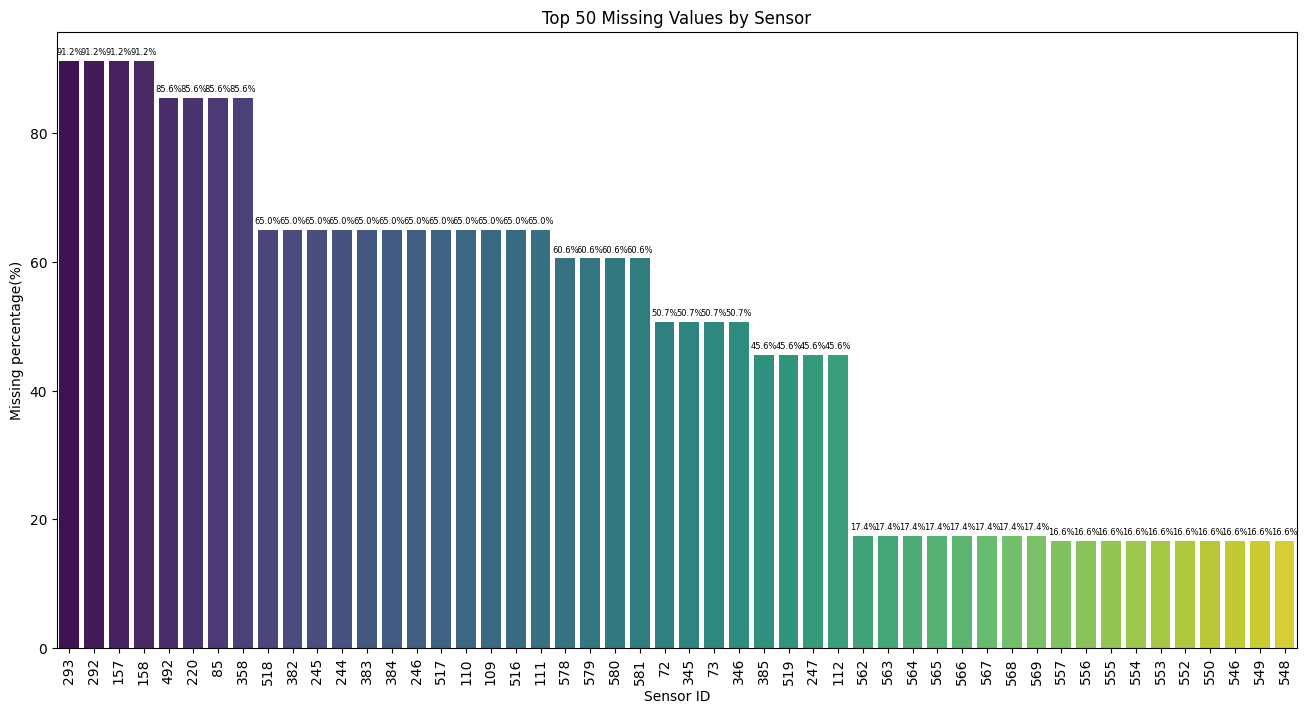

In [3]:
# 그래프 그리기(결측치 비율 top50 columns를 bar plot으로 시각화)

# secom dataset의 결측치의 비율을 "null_counts" Series로 저장
null_percent = my_data.isnull().mean()*100
# 상위 50개의 데이터만 추출
null_top50 = null_percent.sort_values(ascending=False).head(50)

plt.figure(figsize=(16,8))

# 막대그래프 작성
ax = sns.barplot(x=null_top50.index, y=null_top50.values, palette='viridis')

# 각 막대의 위에 값 레이블 표시
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3, fontsize=6)
"""
ax.containers: 막대그래프 지칭
fmt='%.1f%%': "%.1f"(소수점 첫째까지 표시), "%%"(뒤에 % 붙임)
padding: 그래프와 간격 띄우기
"""

plt.title("Top 50 Missing Values by Sensor")
plt.xlabel("Sensor ID")
plt.ylabel("Missing percentage(%)")
# x축 눈금의 값을 반시계 방향으로 90도 회전
plt.xticks(rotation=90)

plt.show()

In [4]:
# constant columns 제거
n_unique = my_data.nunique()
constant_cols = n_unique[n_unique <= 1].index

print(f"상수 열의 개수: {len(constant_cols)}")
print(f"상수 열 목록: {constant_cols.tolist()}")
""".tolist(): 판다스나 넘파이의 인덱스나 시리즈 객체를 파이썬 기본 리스트 형태로 변환"""

my_data_dropped1 = my_data.drop(columns=constant_cols)

print(f"제거된 상수 열 개수: {len(constant_cols)}")
print(f"원본 열 개수: {my_data.shape[1]}")
print(f"제거 후 열 개수: {my_data_dropped1.shape[1]}")

""".shape[?}: 0 -> 행이 개수, 1 -> 열의 개수"""

상수 열의 개수: 116
상수 열 목록: ['5', '13', '42', '49', '52', '69', '97', '141', '149', '178', '179', '186', '189', '190', '191', '192', '193', '194', '226', '229', '230', '231', '232', '233', '234', '235', '236', '237', '240', '241', '242', '243', '256', '257', '258', '259', '260', '261', '262', '263', '264', '265', '266', '276', '284', '313', '314', '315', '322', '325', '326', '327', '328', '329', '330', '364', '369', '370', '371', '372', '373', '374', '375', '378', '379', '380', '381', '394', '395', '396', '397', '398', '399', '400', '401', '402', '403', '404', '414', '422', '449', '450', '451', '458', '461', '462', '463', '464', '465', '466', '481', '498', '501', '502', '503', '504', '505', '506', '507', '508', '509', '512', '513', '514', '515', '528', '529', '530', '531', '532', '533', '534', '535', '536', '537', '538']
제거된 상수 열 개수: 116
원본 열 개수: 592
제거 후 열 개수: 476


'.shape[?}: 0 -> 행이 개수, 1 -> 열의 개수'

In [5]:
# 결측 여부와 불량률 간의 연관성 확인

# 불량률 평균을 구하기 위해 불량=1, 정상=0인 시리즈 생성
labels = (my_data['Pass/Fail'] == 1).astype(int)

# 결측치가 존재하는 열만 추출
null_cols = my_data_dropped1.columns[my_data_dropped1.isnull().any()]

# 각 열에서 결측 여부와 불량률 관계 분석
results = []

# 결측일때의 불량률과, 정상일때의 불량률 비교
for col in null_cols:
    # my_data_dropped1 중 결측치를 가지는 열의 각 행들을 1(결측), 0(정상)으로 나타내는 시리즈
    is_null = my_data_dropped1[col].isnull().astype(int)
    # is_null이 1(결측)인 행번호의 labels 값들의 평균을 반환
    fail_when_null = labels[is_null == 1].mean()
    # is_null이 0(정상)인 행번호의 labels 값들의 평균을 반환
    fail_when_not_null = labels[is_null == 0].mean()
    results.append({
        'column': col,
        'null_ratio': is_null.mean(),
        'fail_rate_when_null': fail_when_null,
        'fail_rate_when_not_null': fail_when_not_null,
        'diff': abs(fail_when_null - fail_when_not_null)
    })

result_df = pd.DataFrame(results).sort_values('diff', ascending=False)
print(result_df.head(20))

# diff가 상위인 행의 결츨비율 매우 작음 -> 결측 비율이 0.05 이상인 열들에 대해서 비교
meaningful = result_df[result_df['null_ratio'] >= 0.05].sort_values('diff', ascending=False)
print(f"해당 열 개수: {len(meaningful)}")
print(meaningful.head(20))

    column  null_ratio  fail_rate_when_null  fail_rate_when_not_null      diff
28      31    0.001276                  0.5                 0.065815  0.434185
24      27    0.001276                  0.5                 0.065815  0.434185
27      30    0.001276                  0.5                 0.065815  0.434185
26      29    0.001276                  0.5                 0.065815  0.434185
25      28    0.001276                  0.5                 0.065815  0.434185
22      25    0.001276                  0.5                 0.065815  0.434185
23      26    0.001276                  0.5                 0.065815  0.434185
21      24    0.001276                  0.5                 0.065815  0.434185
20      23    0.001276                  0.5                 0.065815  0.434185
321    435    0.001276                  0.5                 0.065815  0.434185
19      22    0.001276                  0.5                 0.065815  0.434185
18      21    0.001276                  0.5         

In [6]:
# 확인 결과, 유의미한 비율의 결측치를 갖는 열에서, diff가 매우 작게 나타나는 것을 볼때, 결측 유무가 불량과 거의 관계 없음을 알 수 있다.
# -> 45.6% 이상의 결측 비율을 갖는 열은 제거(45.6%에서 불연속 변곡 발생)
# -> 그 이하의 열은 대체: 중앙값을 대체하여, 데이터 왜곡(중앙값 스파이크, 가짜 상봉형)이 심하게 발생하는 문제가 있었으므로, KNN Imputer로 대체

In [7]:
# KNN Imputer 변환을 위해 "Time"을 숫자로 변환하기 전, 오류 방지를 위해 결측칙 있는지 우선 확인
print(my_data_dropped1['Time'].isnull().sum())

0


In [8]:
# 결측치가 없으므로 숫자로 변환
my_data_dropped1['Time'] = my_data_dropped1['Time'].astype('int64')

In [9]:
# 45.6% 이상 결측 열 제거
cols_to_drop = null_percent[null_percent >= 45.6].index
my_data_dropped2 = my_data_dropped1.drop(columns=cols_to_drop)

print(f"제거된 열 개수: {len(cols_to_drop)}")
print(f"제거 후 열 개수: {my_data_dropped2.shape[1]}")

# 나머지 결측치 KNN Imputer 대체
from sklearn.impute import KNNImputer

imputer = KNNImputer(n_neighbors=5)
final_data = pd.DataFrame(imputer.fit_transform(my_data_dropped2), columns=my_data_dropped2.columns)

# 데이터 검토: 결측치가 0이고, 행은 그대로, 열은 감소해야 함.
print(f"결측치 수: {final_data.isnull().sum().sum()}")
print(f"원본: {my_data.shape}")
print(f"최종: {final_data.shape}")

제거된 열 개수: 32
제거 후 열 개수: 444
결측치 수: 0
원본: (1567, 592)
최종: (1567, 444)


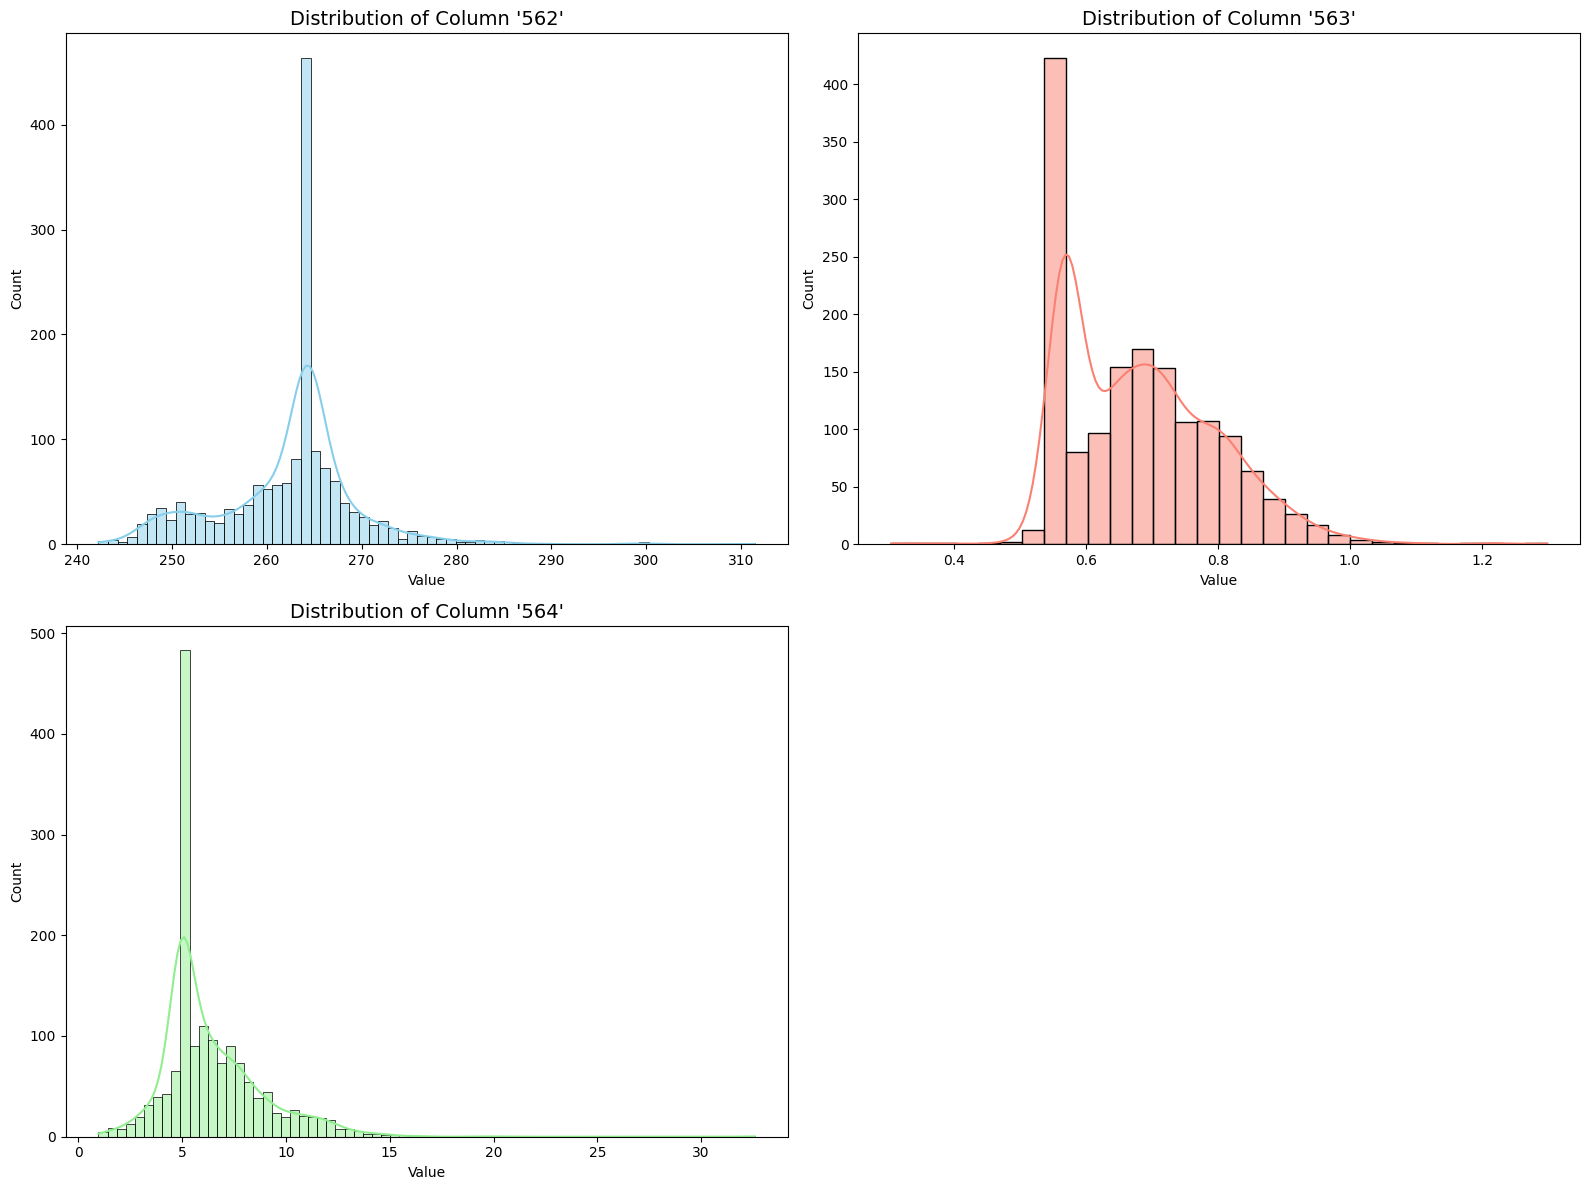

In [10]:
# 중앙값 처리 방식에서 문제를 보였던, 562, 563, 564 열 재확인
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
"""
fig: plot ouput 전체를 관리하는 객체
axes: 각각의 칸들을 답고 있는 리스트
plt.subplot(a, b): a -> 행 개수, b -> 열 개수  
"""
sns.histplot(final_data['562'], kde=True, ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title("Distribution of Column '562'", fontsize=14)
axes[0, 0].set_xlabel("Value")

sns.histplot(final_data['563'], kde=True, ax=axes[0, 1], color='salmon')
axes[0, 1].set_title("Distribution of Column '563'", fontsize=14)
axes[0, 1].set_xlabel("Value")

sns.histplot(final_data['564'], kde=True, ax=axes[1, 0], color='lightgreen')
axes[1, 0].set_title("Distribution of Column '564'", fontsize=14)
axes[1, 0].set_xlabel("Value")

# 마지막 칸[1,1] 숨기기
axes[1, 1].axis('off')

# 그래프 간 간격 자동 조절
plt.tight_layout()
plt.show()

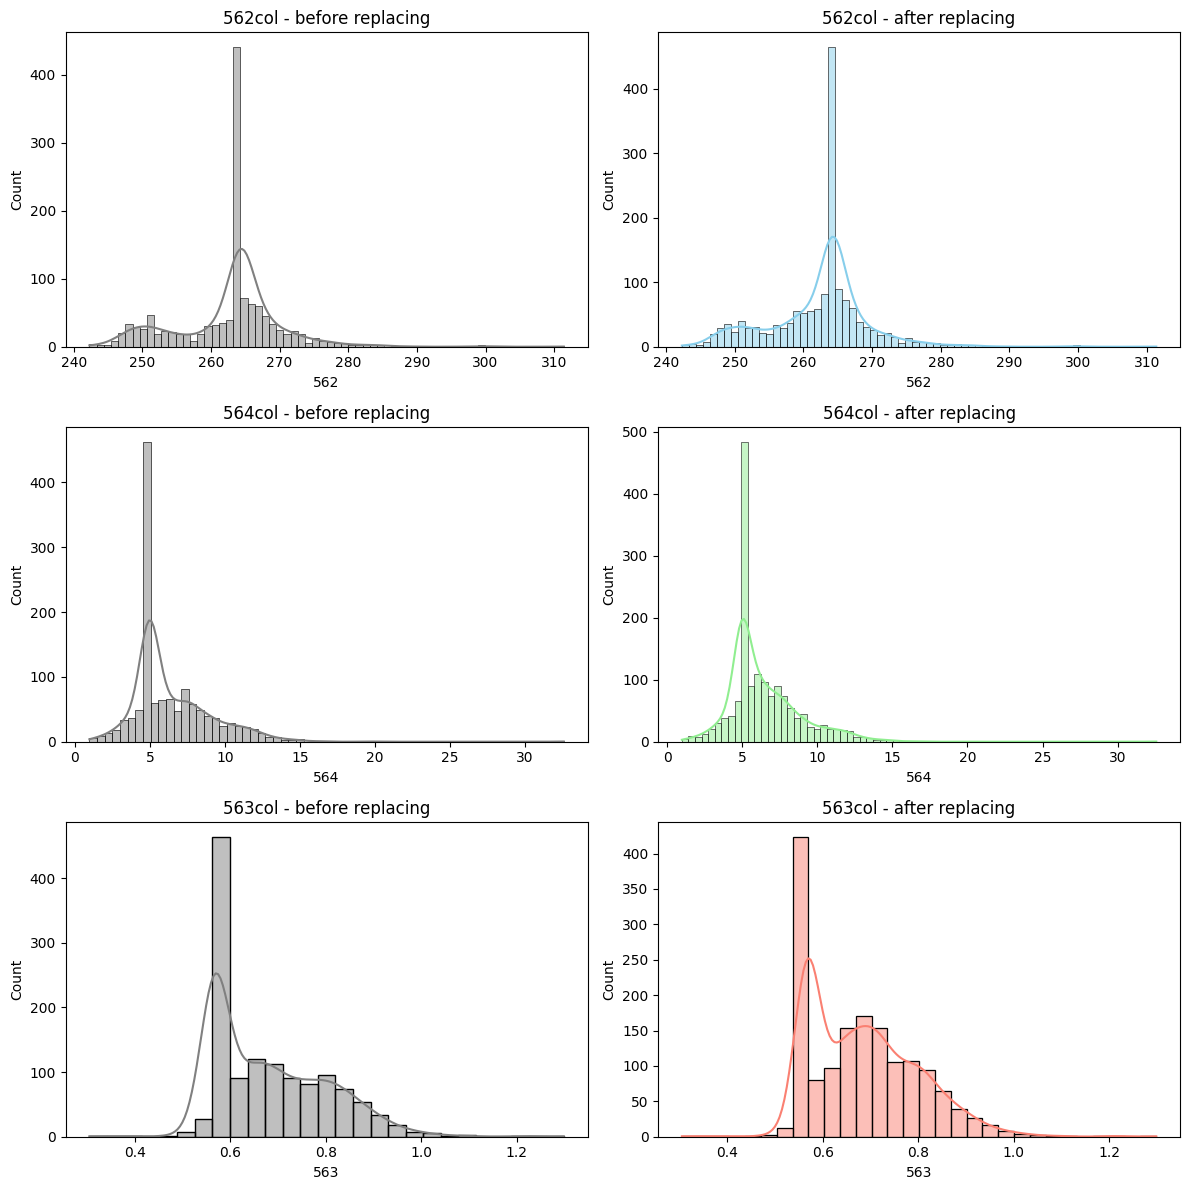

In [11]:
# 그래프의 형태의 원인이 대체인지 원본데이터 자체의 특성인지 확인 필요
fig, axes = plt.subplots(3, 2, figsize=(12, 12))

# 562 대체 전(결측치 제외)
sns.histplot(my_data_dropped2['562'], kde=True, ax=axes[0,0], color='gray')
axes[0,0].set_title("562col - before replacing")
# 562 대체 후
sns.histplot(final_data['562'], kde=True, ax=axes[0,1], color='skyblue')
axes[0,1].set_title("562col - after replacing")

# 564 대체 전(결측치 제외)
sns.histplot(my_data_dropped2['564'], kde=True, ax=axes[1,0], color='gray')
axes[1,0].set_title("564col - before replacing")
# 564 대체 후
sns.histplot(final_data['564'], kde=True, ax=axes[1,1], color='lightgreen')
axes[1,1].set_title("564col - after replacing")

# 563 대체 전(결측치 제외)
sns.histplot(my_data_dropped2['563'], kde=True, ax=axes[2,0], color='gray')
axes[2,0].set_title("563col - before replacing")
# 563 대체 후
sns.histplot(final_data['563'], kde=True, ax=axes[2,1], color='salmon')
axes[2,1].set_title("563col - after replacing")

plt.tight_layout()
plt.show()

In [12]:
# 562, 564의 중앙값 스파이크는 원본 그래프 자체의 성질임 -> 대체가 잘 이뤄짐.
# 563은 현재 약한 가짜 쌍봉형 생성 -> 중앙값 대체보다 훨씬 약하며, 17.4% 대체를 고려할때 불가피하다고 판단.
# 즉, 현재 대체 선택지 중 KNN이 가장 나은 방식으로 고려.